# Fundamental Matrix and RANSAC

In this exercise, you will learn:
- how to estimate the fundamental matrix $F$ that geometrically relates two views of the same scene
- how to make your estimation more robust to outliers and noise which is important in practice

For some functions we already provide some draft implementation that you just need to complete. This is supposed to help you identifying the next steps. Still, if it does not fit your idea you may ignore it.

## 1. Setup

Load all libraries and both views that we will work with. In this exercise you are given two views again and matching key points which we extracted in advance.

In [ ]:
%pip install numpy matplotlib pillow scipy

import numpy as np
import matplotlib.pyplot as plt
from PIL import Image
from scipy import signal

In [4]:
from matplotlib.patches import ConnectionPatch

# use this function to visualize the matches
def plot_matches(img1, img2, keypoints1, keypoints2):
    fig, axes = plt.subplots(1,2,figsize=(16,7))
    
    # draw images
    axes[0].imshow(img1)
    axes[1].imshow(img2)
    
    # draw matches
    for kp1, kp2 in zip(keypoints1, keypoints2):
        c = np.random.rand(3)
        con = ConnectionPatch(xyA=kp1, coordsA=axes[0].transData,
                              xyB=kp2, coordsB=axes[1].transData, color=c)
        fig.add_artist(con)
        axes[0].plot(*kp1, color=c, marker='x')
        axes[1].plot(*kp2, color=c, marker='x')
    
    plt.show()

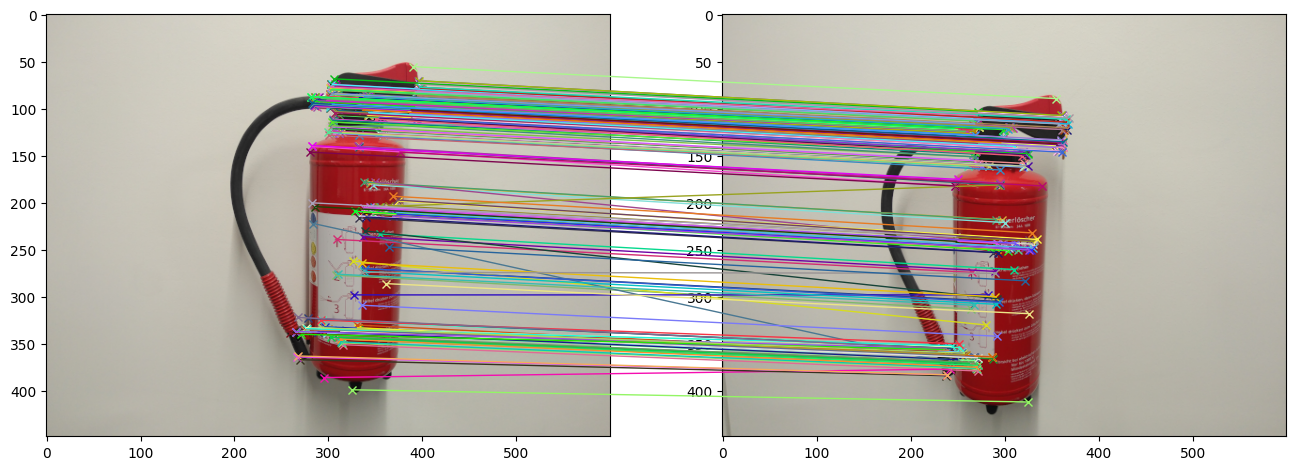

In [5]:
# Load images
view1 = np.array(Image.open("data/exercise3/view1.png")) / 255
view2 = np.array(Image.open("data/exercise3/view2.png")) / 255

# Load matching keypoints
with np.load("data/exercise4/keypoints.npz") as data:
    keypoints1 = data["view1"]
    keypoints2 = data["view2"]
    
plot_matches(view1, view2, keypoints1, keypoints2)

### 4.1. Fundamental Matrix
We begin with computing the fundamental matrix $F$ which defines the epipolar constraints for two views of two uncalibrated cameras. It determines the lines corresponding points can lie on. If we have a total of eight pairs of corresponding points this matrix can be estimated using the 8-point algorithm discussed in the lecture, see slide deck 

Your task now is to use eight point matches and compute the fundamental matrix $F$ by performing a direct linear transform and then decompose the resulting matrix using SVD. You might want to look at the slides again.

Hint: Use `numpy.linalg.svd` for singular value decomposition and do not forget to rescale the point coordinates to obtain stable results (this is termed 'conditioning' on the slides).

In [ ]:
def find_fundamental_svd(kps1, kps2):
    """
    Estimate fundamental matrix using SVD 
    :param kps1: keypoints extracted from view1 in homogeneous coordinates
    :param kps2: keypoints extracted from view2 in homogeneous coordinates
    """
    # condition points
    # Compute mean and scale for normalization
    mean1 = np.mean(kps1[:, :2], axis=0)
    mean2 = np.mean(kps2[:, :2], axis=0)
    
    scale1 = np.sqrt(2) / np.mean(np.sqrt(np.sum((kps1[:, :2] - mean1)**2, axis=1)))
    scale2 = np.sqrt(2) / np.mean(np.sqrt(np.sum((kps2[:, :2] - mean2)**2, axis=1)))
    
    # Normalization matrices
    T1 = np.array([[scale1, 0, -scale1 * mean1[0]],
                   [0, scale1, -scale1 * mean1[1]],
                   [0, 0, 1]])
    
    T2 = np.array([[scale2, 0, -scale2 * mean2[0]],
                   [0, scale2, -scale2 * mean2[1]],
                   [0, 0, 1]])
    
    # Normalize points
    kps1_norm = (T1 @ kps1.T).T
    kps2_norm = (T2 @ kps2.T).T
    
    # collect equations
    # Build matrix A where each row is [x1*x2, x1*y2, x1, y1*x2, y1*y2, y1, x2, y2, 1]
    n = kps1.shape[0]
    A = np.zeros((n, 9))
    
    for i in range(n):
        x1, y1, _ = kps1_norm[i]
        x2, y2, _ = kps2_norm[i]
        A[i] = [x2*x1, x2*y1, x2, y2*x1, y2*y1, y2, x1, y1, 1]
    
    # solve for fundamental matrix using SVD
    # F is the last column of V (corresponding to smallest singular value)
    U, S, Vt = np.linalg.svd(A)
    F_norm = Vt[-1].reshape(3, 3)

    # uncondition F
    # F = T2^T @ F_norm @ T1
    F = T2.T @ F_norm @ T1
    
    # make rank 2
    # Force rank 2 by setting smallest singular value to 0
    U, S, Vt = np.linalg.svd(F)
    S[2] = 0
    F = U @ np.diag(S) @ Vt
        
    return F

In [ ]:
# compute F from a set of 8 point matches
# Convert keypoints to homogeneous coordinates
kps1_homog = np.hstack([keypoints1, np.ones((keypoints1.shape[0], 1))])
kps2_homog = np.hstack([keypoints2, np.ones((keypoints2.shape[0], 1))])

# Use first 8 point matches to compute F
F = find_fundamental_svd(kps1_homog[:8], kps2_homog[:8])
print("Fundamental matrix F:")
print(F)

Fundamental matrix F:
[[ 6.00918023e-06  9.09842913e-05 -2.24830585e-02]
 [-7.62765654e-05  9.67692899e-06  1.70336282e-02]
 [ 2.08118714e-02 -2.13249252e-02 -3.42102629e-01]]


Check your code by visualizing the epipolar lines of you key points. We provide the function for this below. What do you see?

In [8]:
def visualize_epipolar_lines(img1, img2, keypoints1, keypoints2, F):
    """
    :params img1: view 1
    :params img2: view 2
    :params keypoints1: the key points from view 1 matching
                        with the key points from view 2
                        --> they are expected to be in homogenous coordinates
    :params keypoints2: the key points from view 2 matching
                        with the key points from view 1
                        --> they are expected to be in homogenous coordinates
    :params F: the fundamental matrix
    """
    fig, axes = plt.subplots(1,2,figsize=(16,7))
    
    # draw images
    axes[0].imshow(img1)
    axes[1].imshow(img2)
    res = img1.shape[:2]
    
    for color_index, (kp1, kp2) in enumerate(zip(keypoints1, keypoints2)):
        c = np.random.rand(3)
        
        # plot points
        axes[0].plot(kp1[0], kp1[1], color=c, marker='o',markersize=5)
        axes[1].plot(kp2[0], kp2[1], color=c, marker='o',markersize=5)
        
        # compute epi lines
        epi_line_2 = kp1[None,...] @ F
        epi_line_1 = F @ kp2[None,...].T
        
        # plot lines
        for i, line in enumerate([epi_line_1, epi_line_2]):
            line = line.flatten()
            fn = lambda x: (line[0]*x + line[2]) / -line[1]
            xs = np.arange(res[1])
            axes[i].plot(xs, fn(xs), c=c)
    
    axes[0].set_ylim((res[0],0))
    axes[1].set_ylim((res[0],0))
    
    plt.show()

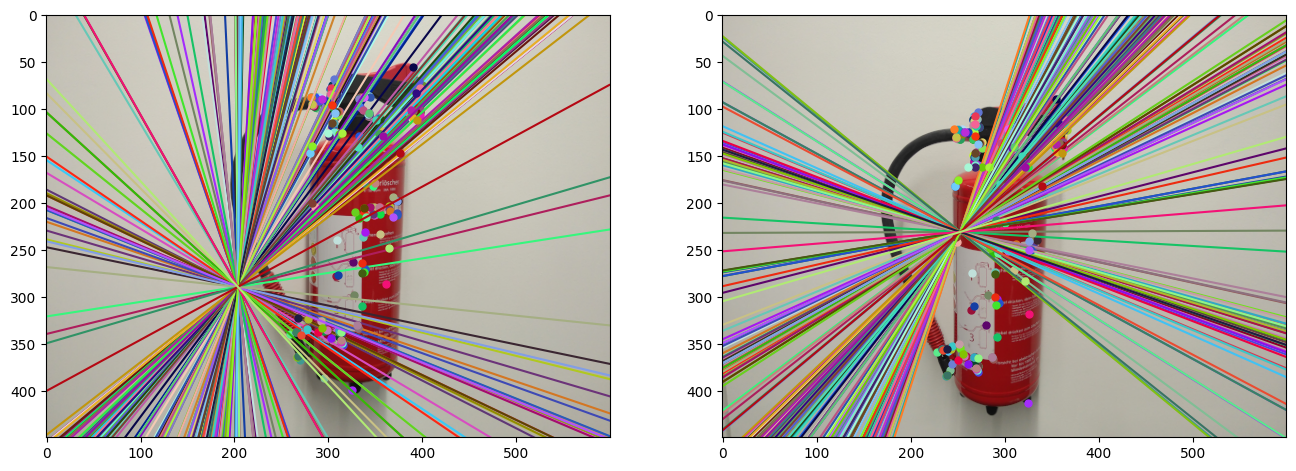

In [ ]:
# Visualize epipolar lines
visualize_epipolar_lines(view1, view2, kps1_homog, kps2_homog, F)

Also, compute the algebraic error, i.e. how well is the epipolar contraint $x_0^TFx_1=0$ met.
Furthermore, calculate the geometric error, i.e. are the points far away from the epipolar lines.
What do the algebraic and geometric error values show you?

In [10]:
def algebraic_error(keypoints1, keypoints2, F):
    errors = []
    for kp1, kp2 in zip(keypoints1, keypoints2):
        error = np.abs(kp1[None,...] @ F @ kp2[None,...].T)
        errors.append(error.item())
    return errors

def geometric_error(keypoints1, keypoints2, F):
    errors = []
    for kp1, kp2 in zip(keypoints1, keypoints2):
        x1F = kp1[None,...] @ F
        Fx2 = F @ kp2[None,...].T
        x1Fx2 = x1F @ kp2[None,...].T
        
        part1 = 1/(x1F.flatten()[0] ** 2 + x1F.flatten()[1] ** 2)
        part2 = 1/(Fx2.flatten()[0] ** 2 + Fx2.flatten()[1] ** 2)
        
        error = np.sqrt(x1Fx2 ** 2 * (part1 + part2))
        errors.append(error.item())
    return errors

In [ ]:
# Compute errors
alg_errors = algebraic_error(kps1_homog, kps2_homog, F)
geom_errors = geometric_error(kps1_homog, kps2_homog, F)

print(f"Algebraic errors - Mean: {np.mean(alg_errors):.4f}, Std: {np.std(alg_errors):.4f}")
print(f"Geometric errors - Mean: {np.mean(geom_errors):.4f}, Std: {np.std(geom_errors):.4f}")
print(f"\nFirst 10 algebraic errors: {alg_errors[:10]}")
print(f"First 10 geometric errors: {geom_errors[:10]}")

Algebraic errors - Mean: 0.5590, Std: 0.4029
Geometric errors - Mean: 80.2193, Std: 57.2303

First 10 algebraic errors: [0.49157946159596566, 0.5534546030185785, 0.05165254358921878, 0.7919776585303508, 0.1063440964947242, 0.6119254876429077, 0.6954415426915439, 0.5454254582991345, 0.5271657010148019, 0.9958469506507868]
First 10 geometric errors: [137.16730003622303, 65.20630570590312, 4.258753448487018, 133.62757938278074, 9.043371353373006, 77.81245847661737, 137.81260252590485, 60.2339946601085, 58.7804262445837, 156.6892967781354]


The visualization you saw with lines converging to epipoles and high errors (mean geometric error ~80) is actually expected when using just the first 8 points! Here's why:

- The first 8 points may contain outliers - feature matching isn't perfect
- No robustness - the basic 8-point algorithm is sensitive to even one bad match
- This demonstrates the problem RANSAC solves - you need robust estimation

### 4.2 Robust estimation using RANSAC
As some of the point matches suffer from noise or are even incorrect. The risk of obtaining an incorrect fundamental matrix by relying just on eight points is high. Hence, we are looking for a more robust version of estimating $F$. To do this, the RANSAC algorithm was introduced in the lecture. Your final task is to complete the implementation for fundamental matrix estimation by using RANSAC. You can compare the errors and epipolar lines of a robustly estimated $F$ with the one from the previous task.

In [ ]:
def find_fundamental_ransac(keypoints1, keypoints2, num_samples=8, threshold=5, iterations=5000, min_inliers=30):
    """
    Optimizes fundamental matrix parameters using RANSAC algorithm
    :params keypoints1: the key points from view 1 matching
                        with the key points from view 2
                        --> they are expected to be in homogenous coordinates
    :params keypoints2: the key points from view 2 matching
                        with the key points from view 1
                        --> they are expected to be in homogenous coordinates
    :param num_samples: the number of samples to draw in each iteration
    :param threshold: determines the error value at which we decide for inlier or outlier
    :iterations: maximum number of iterations
    :returns: fundamental matrix and a binary mask indicating the inlier points in keypoints1 and keypoints2
    
    """
    best_F = None
    best_inliers = None
    best_inlier_count = 0
    
    n_points = len(keypoints1)
    
    for i in range(iterations):
        # Randomly sample num_samples point correspondences
        indices = np.random.choice(n_points, num_samples, replace=False)
        sample_kps1 = keypoints1[indices]
        sample_kps2 = keypoints2[indices]
        
        # Estimate F from the sample
        F_candidate = find_fundamental_svd(sample_kps1, sample_kps2)
        
        # Compute geometric errors for all points
        errors = geometric_error(keypoints1, keypoints2, F_candidate)
        
        # Determine inliers
        inliers = np.array(errors) < threshold
        inlier_count = np.sum(inliers)
        
        # Update best model if we found more inliers
        if inlier_count > best_inlier_count:
            best_inlier_count = inlier_count
            best_inliers = inliers
            best_F = F_candidate
            
        # Early termination if we have enough inliers
        if inlier_count >= min_inliers and inlier_count > n_points * 0.8:
            break
    
    # Refine F using all inliers
    if best_inliers is not None and np.sum(best_inliers) >= num_samples:
        inlier_kps1 = keypoints1[best_inliers]
        inlier_kps2 = keypoints2[best_inliers]
        best_F = find_fundamental_svd(inlier_kps1, inlier_kps2)
    
    print(f"RANSAC found {best_inlier_count} inliers out of {n_points} points")
        
    return best_F, best_inliers

In [ ]:
F_ransac, inliers = find_fundamental_ransac(kps1_homog, kps2_homog, num_samples=8, threshold=5, iterations=5000)
print("\nFundamental matrix F (RANSAC):")
print(F_ransac)
print(f"\nInlier ratio: {np.sum(inliers)/len(inliers):.2%}")

Now visualize again the epipolar lines and compute the errors. What has changed?

In [ ]:
# Visualize epipolar lines with RANSAC F
visualize_epipolar_lines(view1, view2, kps1_homog[inliers], kps2_homog[inliers], F_ransac)

# Compute errors with RANSAC F
alg_errors_ransac = algebraic_error(kps1_homog[inliers], kps2_homog[inliers], F_ransac)
geom_errors_ransac = geometric_error(kps1_homog[inliers], kps2_homog[inliers], F_ransac)

print(f"\nRANSAC Results (inliers only):")
print(f"Algebraic errors - Mean: {np.mean(alg_errors_ransac):.4f}, Std: {np.std(alg_errors_ransac):.4f}")
print(f"Geometric errors - Mean: {np.mean(geom_errors_ransac):.4f}, Std: {np.std(geom_errors_ransac):.4f}")

print(f"\nComparison with 8-point (all points):")
print(f"8-point Algebraic error mean: {np.mean(alg_errors):.4f}")
print(f"RANSAC Algebraic error mean: {np.mean(alg_errors_ransac):.4f}")
print(f"8-point Geometric error mean: {np.mean(geom_errors):.4f}")
print(f"RANSAC Geometric error mean: {np.mean(geom_errors_ransac):.4f}")